In [19]:
!pip install yfinance mplfinance pandas numpy
!pip install tensorflow


   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 1.3/351.2 MB 9.5 MB/s eta 0:00:37
   ---------------------------------------- 3.7/351.2 MB 11.0 MB/s eta 0:00:32
    --------------------------------------- 6.3/351.2 MB 11.3 MB/s eta 0:00:31
    --------------------------------------- 8.7/351.2 MB 11.5 MB/s eta 0:00:30
   - -------------------------------------- 11.0/351.2 MB 11.6 MB/s eta 0:00:30
   - -------------------------------------- 13.6/351.2 MB 11.6 MB/s eta 0:00:30
   - -------------------------------------- 16.0/351.2 MB 11.6 MB/s eta 0:00:29
   -- ------------------------------------- 18.6/351.2 MB 11.7 MB/s eta 0:00:29
   -- ------------------------------------- 21.0/351.2 MB 11.7 MB/s eta 0:00:29
   -- ------------------------------------- 23.6/351.2 MB 11.7 MB/s eta 0:00:29
   -- ------------------------------------- 26.2/351.2 MB 11.7 MB/s eta 0:00:28
   --- ------------------------------------ 28.6/351.2

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.36.0 which is incompatible.


In [39]:
import os
import mplfinance as mpf
import yfinance as yf

# 1. Fetch the last 60 days of TSM data
df = yf.download("TSM", period="60d", interval="1d", multi_level_index=False)

# Take the most recent 30 days as an example
df_30 = df.tail(30)

# 2. Manually define a minimalist style
# Custom market colors: green for up, red for down
mc = mpf.make_marketcolors(
    up="g", down="r", 
    edge="inherit", wick="inherit"
)

# Create a clean custom style: black background, no grid
custom_style = mpf.make_mpf_style(
    marketcolors=mc,
    facecolor='black',       # Black chart background
    edgecolor='black',       # Black edge color
    figcolor='black',        # Black figure background
    gridstyle=""             # Hide grid
)

# 3. Set the save path
# Ensure the directory exists
os.makedirs("Dataset/W_Bottom", exist_ok=True)
output_filename = "Dataset/W_Bottom/tsm_test.png"

# 4. Plot and save the image
mpf.plot(
    df_30,
    type="candle",
    style=custom_style,
    axisoff=True,  # Turn off axes! Axes are noise for the CNN model
    savefig=dict(fname=output_filename, dpi=100, pad_inches=0),
)

print(f"Image successfully generated! Saved at: {output_filename}")

[*********************100%***********************]  1 of 1 completed

Image successfully generated! Saved at: Dataset/W_Bottom/tsm_test.png


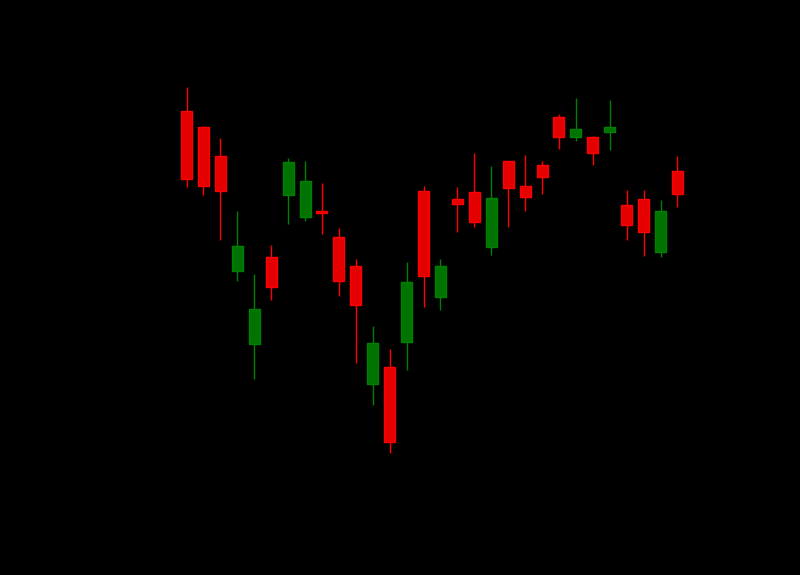

In [11]:
from IPython.display import Image

Image(filename="Dataset/W_Bottom/tsm_test.png")

In [15]:
import os
import mplfinance as mpf
import yfinance as yf
import pandas as pd

# 1. Prepare output directory
output_folder = "Dataset/Unlabeled"
os.makedirs(output_folder, exist_ok=True)

# Custom market colors and style
mc = mpf.make_marketcolors(up="g", down="r", edge="inherit", wick="inherit")
custom_style = mpf.make_mpf_style(
    marketcolors=mc, facecolor='black', edgecolor='black', figcolor='black', gridstyle=""
)

# 2. Define the ticker list (selecting stocks with diverse price actions)
tickers = [
    "MU","AAOI","GLD","PDD"
    # "AAPL", "MSFT", "AMD", "QCOM",  # Tech & Semiconductors
    # "BA", "DIS", "NKE", "MCD",      # Traditional & Consumer
    # "BABA", "TCEHY"                 # Chinese Tech (high volatility)
]

# 3. Sliding window parameters
window_size = 60  # 60 days to allow Head and Shoulders patterns to form
step_size = 10    # 10-day step size to avoid generating identical images

generate_count = 0

# 4. Double loop: Iterate through tickers, then time windows
for ticker in tickers:
    print(f"\nProcessing {ticker}...")
    df = yf.download(ticker, period="3y", interval="1d", multi_level_index=False)
    
    total_days = len(df)
    
    # Implement step_size to control the sliding window
    for i in range(0, total_days - window_size + 1, step_size):
        df_window = df.iloc[i : i + window_size]
        
        filename = f"{ticker}_{generate_count:04d}.png"
        filepath = os.path.join(output_folder, filename)
        
        mpf.plot(
            df_window,
            type="candle",
            style=custom_style,
            axisoff=True,
            savefig=dict(fname=filepath, dpi=64, pad_inches=0)
        )
        
        generate_count += 1
        if generate_count % 50 == 0:
            print(f"Generated {generate_count} images...")

print(f"\nGeneration complete! A total of {generate_count} representative images have been created.")


Processing MU...


[*********************100%***********************]  1 of 1 completed


Generated 50 images...


[*********************100%***********************]  1 of 1 completed


Processing AAOI...


...

[*********************100%***********************]  1 of 1 completed


Processing GLD...


Generated 150 images...
Generated 200 images...

Processing PDD...


[*********************100%***********************]  1 of 1 completed


Generated 250 images...

Generation complete! A total of 280 representative images have been created.


In [17]:
#Use VGG style network
import tensorflow as tf
import matplotlib.pyplot as plt


# 1. Define paths and parameters
dataset_dir = "Dataset"
batch_size = 16  #mini batch size of 16
img_height = 64
img_width = 64

# 2. Load the dataset
# Split the data: 80% for training, 20% for validation
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Three types: W_Bottom, Head_Shoulder, No_Pattern
class_names = train_ds.class_names
print(f"Detected classes: {class_names}")

# 3. Build the CNN Model
model = tf.keras.Sequential([
    # Do the data augmentation
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1, input_shape=(img_height, img_width, 3)),
    tf.keras.layers.RandomZoom(height_factor=0.1, width_factor=0.1),
    
    tf.keras.layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    
    # Block 1: Conv2D with 32 filters, 3x3 kernel, ReLU activation
    # Because the image is only candlestick chart, no need filter as large as 64
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    
    # Block 2: Conv2D with 64 filters, 3x3 kernel, ReLU activation
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    
    # Flatten the tensor output from the convolutional layers
    tf.keras.layers.Flatten(),

    # The FC layer
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.6), 
    
    # Final Output Layer: Units should equal the number of classes. 
    # Use the appropriate activation for multi-class classification.
    tf.keras.layers.Dense(units=len(class_names), activation='softmax')
])

# 4. Compile the model
# EXERCISE: Use the standard optimizer for deep learning and the correct loss function.
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

model.summary()

# Add this to prevent all predicting to no_pattern
weights_dict = {
    0: 1.15, 
    1: 1.0,   
    2: 1.15    
}
# 5. Train the model
print("\nStarting model training...")
epochs = 20
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    class_weight=weights_dict
)

model.save('stock_pattern_cnn.keras')
print("\nModel saved as 'stock_pattern_cnn.keras'!")

Found 240 files belonging to 3 classes.
Using 192 files for training.
Found 240 files belonging to 3 classes.
Using 48 files for validation.
Detected classes: ['Head_Shoulder', 'No_Pattern', 'W_Bottom']


C:\Users\SAM H\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_translation_3                 │ (None, 64, 64, 3)           │               0 │
│ (RandomTranslation)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_zoom_3 (RandomZoom)           │ (None, 64, 64, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_3 (Rescaling)              │ (None, 64, 64, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │       1,048,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,068,227 (4.07 MB)

 Trainable params: 1,068,227 (4.07 MB)

 Non-trainable params: 0 (0.00 B)


Starting model training...
Epoch 1/20


C:\Users\SAM H\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.7656 - loss: 0.8718 - val_accuracy: 0.7708 - val_loss: 0.7663
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7760 - loss: 0.7789 - val_accuracy: 0.7708 - val_loss: 0.7939
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7760 - loss: 0.7433 - val_accuracy: 0.7708 - val_loss: 0.7103
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7760 - loss: 0.6881 - val_accuracy: 0.7708 - val_loss: 0.6644
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7760 - loss: 0.6851 - val_accuracy: 0.7708 - val_loss: 0.7239
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7448 - loss: 0.6895 - val_accuracy: 0.7708 - val_loss: 0.5870
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7812 - loss: 0.6209 - val_accuracy: 0.7708 - val_loss: 0.6661
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7552 - loss: 0.6677 - val_accuracy: 0.7083 - val_loss: 0.

In [1]:
import os
import numpy as np
import tensorflow as tf
import yfinance as yf
import mplfinance as mpf
import pandas as pd
import requests

# 1. Load the trained model
print("Loading CNN model...")
model = tf.keras.models.load_model('stock_pattern_cnn.keras')
# Define classes ( match the alphabetical order of dataset folders)
class_names = ['Head_Shoulder', 'No_Pattern', 'W_Bottom']

print("Loading list of stocks...")
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
}
try:
    # Use request to access wikipedia and retrieve the data
    response = requests.get(url, headers=headers)
    response.raise_for_status() # throw exception if something happens
    
    
    tables = pd.read_html(response.text)
    
    # Get the list of stocks
    sp500_df = tables[0]
    tickers = sp500_df['Symbol'].tolist()
    
    #  change BRK.B to BRK-B
    tickers = [ticker.replace('.', '-') for ticker in tickers]
    
    print(f"✅ Load {len(tickers)} stocks successfully！")
    print("-" * 50)
    
except Exception as e:
    print(f"Error: {e}")
    
# tables = pd.read_html(url)
# sp500_df = tables[0]
# tickers = sp500_df['Symbol'].tolist()

# # The observing stock list
# tickers = [ticker.replace('.', '-') for ticker in tickers] 

# 3. Setup temporary folder for daily image generation
temp_folder = "Temp_Scan"
os.makedirs(temp_folder, exist_ok=True)

# Re-use the exact same chart style from training to avoid confusing the model
# For the model to use
mc_model = mpf.make_marketcolors(up="g", down="r", edge="inherit", wick="inherit")
style_model = mpf.make_mpf_style(marketcolors=mc_model, facecolor='black', edgecolor='black', figcolor='black', gridstyle="")

# 2. For showing
style_human = mpf.make_mpf_style(marketcolors=mc_model, gridstyle="--")

print("Starting market scan...\n")
print("-" * 50)
detected_targets = []
# 4. Automate the scanning process
for ticker in tickers:
    try:
        # Fetch the latest 60 days of data
        df = yf.download(ticker, period="60d", interval="1d", multi_level_index=False)
        
        if len(df) < 60:
            continue

        # Define temporary file path
        filepath = os.path.join(temp_folder, f"{ticker}_latest.png")
        
        # Generate the K-line image (invisible to the user)
        mpf.plot(
            df, type="candle", style=style_model, axisoff=True,
            savefig=dict(fname=filepath, dpi=64, pad_inches=0)
        )
        
        # 5. Image Preprocessing for Prediction
        # Load image, resize to 64x64, and convert to array
        img = tf.keras.utils.load_img(filepath, target_size=(64, 64))
        img_array = tf.keras.utils.img_to_array(img)
        # Expand dimensions to match the batch format: (1, 64, 64, 3)
        img_array = tf.expand_dims(img_array, 0) 

        # 6. Make the Prediction
        predictions = model.predict(img_array, verbose=0)
        probabilities = predictions[0]
        
        predicted_index = np.argmax(probabilities)
        predicted_class = class_names[predicted_index]
        confidence = probabilities[predicted_index] * 100
        
        # 7. Output Alert filtering (Only alert if it's a specific pattern with decent confidence)
        if predicted_class != "No_Pattern" and confidence > 50.0:
            print("\n" + "🔥" * 25)
            print(f"🚨 TARGET IDENTIFIED: {ticker}")
            print(f"📈 Pattern: {predicted_class}")
            print(f"🎯 Confidence: {confidence:.2f}%")
            detected_targets.append({
                    "ticker": ticker,
                    "pattern": predicted_class,
                    "confidence": confidence,
                    "image_path": filepath
                })
            # Show the K line image to user 
            # mpf.plot(df, type="candle", style=style_human, title=f"{ticker} - Last 60 Days", volume=False)
            # print("🔥" * 25 + "\n")
        else:
            print(f"[{ticker}] Status normal. (Detected: {predicted_class}, {confidence:.2f}%)")
            
    except Exception as e:
        print(f"Error processing {ticker}: {e}")

print("-" * 50)
print("\nScan completed!")

Loading CNN model...
Loading list of stocks...


C:\Users\SAM H\AppData\Local\Temp\ipykernel_47644\3824152424.py:26: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


✅ Load 503 stocks successfully！
--------------------------------------------------
Starting market scan...

--------------------------------------------------


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

[MMM] Status normal. (Detected: No_Pattern, 98.95%)


...


[*********************100%***********************]  1 of 1 completed

[EXE] Status normal. (Detected: No_Pattern, 76.75%)



[*********************100%***********************]  1 of 1 completed

[EXPE] Status normal. (Detected: No_Pattern, 97.91%)


KeyboardInterrupt: 

In [15]:
%run scanner.py

Loading CNN model...
Loading list of stocks...


C:\Users\SAM H\OneDrive\桌面\DLProj\projpy\scanner.py:27: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)
[*********************100%***********************]  1 of 1 completed

✅ Load 503 stocks successfully！
--------------------------------------------------
Starting market scan...

--------------------------------------------------



[*********************100%***********************]  1 of 1 completed

[MMM] Status normal. (Detected: No_Pattern, 94.30%)


...

[ADP] Status normal. (Detected: No_Pattern, 87.64%)



[*********************100%***********************]  1 of 1 completed

[AZO] Status normal. (Detected: No_Pattern, 99.03%)


[AVY] Status normal. (Detected: No_Pattern, 78.03%)


KeyboardInterrupt: 

In [10]:
%run train_model.py

Found 240 files belonging to 3 classes.
Using 192 files for training.
Found 240 files belonging to 3 classes.
Using 48 files for validation.
Detected classes: ['Head_Shoulder', 'No_Pattern', 'W_Bottom']


C:\Users\SAM H\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_translation                   │ (None, 64, 64, 3)           │               0 │
│ (RandomTranslation)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_zoom (RandomZoom)             │ (None, 64, 64, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 64, 64, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       1,048,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,068,227 (4.07 MB)

 Trainable params: 1,068,227 (4.07 MB)

 Non-trainable params: 0 (0.00 B)


Starting model training...
Epoch 1/20


C:\Users\SAM H\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.7240 - loss: 0.9209 - val_accuracy: 0.7708 - val_loss: 0.8062
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7656 - loss: 0.8050 - val_accuracy: 0.7708 - val_loss: 0.7515
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7760 - loss: 0.7504 - val_accuracy: 0.7708 - val_loss: 0.7182
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7760 - loss: 0.7568 - val_accuracy: 0.7708 - val_loss: 0.7049
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7969 - loss: 0.6476 - val_accuracy: 0.7708 - val_loss: 0.8614
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7240 - loss: 0.7536 - val_accuracy: 0.7083 - val_loss: 0.6574
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7552 - loss: 0.6860 - val_accuracy: 0.7708 - val_loss: 0.6556
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7812 - loss: 0.6350 - val_accuracy: 0.7708 - val_loss: 0.